# **Phase 5: Decision Framework Comparison**
---
Comparison among three independent frameworks of technology-selection: **(i)** cluster-only;
**(ii)** rule-only (process suitability); and **(iii)** hybrid (cluster + rule) frameworks.

In [2]:
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath(".."))

from src.models.cluster_only_rules import assign_cluster_only_decision   
from src.models.suitability_rules import apply_process_rules            
from src.models.rule_only_conversion import assign_rule_only_conversion     
from src.models.wte_conversion_rules import assign_conversion_technology    

df = pd.read_csv("../data/interim/engineered_features_with_cluster.csv")                # Load data

df = assign_cluster_only_decision(df)       # Cluster-only decision
df = apply_process_rules(df)                # Process suitability rules
df = assign_rule_only_conversion(df)        # Rule-only decision
df = assign_conversion_technology(df)       # Hybrid decision

df.to_csv(
    "../data/processed/comparison_decisions.csv",
    index=False
)

In [3]:
df

,Sample_ID,Biomass_Type,Class,Subclass,Ash_db,VM_db,FC_db,C_db,H_db,N_db,...,Moist_ar,Moisture_Penalty,Effective_HHV,Cluster,Final_Tech_ClusterOnly,Primary_Process,Secondary_Process,Constraint_Level,Final_Tech_RuleOnly,Final_Conversion_Technology
0,1,Industrial Processing,Timber industry,Woodchips (Softwood),1.10,81.00,17.90,48.60,6.26,0.20,...,41.2,0.023697,-826.110,1.0,Pyrolysis,Pyrolysis,None,High,Pyrolysis,Pyrolysis
1,3,Agricultural,Animal farming,Chicken manure pellets,32.70,56.20,11.10,30.00,3.91,3.94,...,18.9,0.050251,-222.139,2.0,Further Assessment Needed,Pre-treatment Required,None,Low,Further Assessment Needed,Pyrolysis
2,4,Urban Waste,Biosolids,Treated biosolids,42.80,52.00,5.20,24.70,4.35,4.61,...,8.1,0.109890,-89.886,2.0,Further Assessment Needed,Pre-treatment Required,None,High,Further Assessment Needed,Gasification
3,5,Industrial Processing,Paper industry,Paper sludge,26.20,64.20,9.60,32.40,4.96,0.47,...,7.8,0.113636,-96.152,2.0,Further Assessment Needed,Pre-treatment Required,None,Low,Further Assessment Needed,Pyrolysis
4,6,Industrial Processing,Cotton Industry,Cotton seed hulls,1.90,77.90,20.20,32.50,6.02,0.45,...,11.6,0.079365,-193.768,1.0,Pyrolysis,Pyrolysis,None,Moderate,Pyrolysis,Pyrolysis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,138,Industrial Processing,Other,Hardwood (Eucalyptus),8.00,73.40,18.60,49.00,5.91,0.13,...,6.6,0.131579,-111.496,1.0,Pyrolysis,Pyrolysis,None,Moderate,Pyrolysis,Pyrolysis
131,139,Industrial Processing,Other,Wood waste and plastics waste,8.41,71.05,20.54,45.49,5.68,1.27,...,40.3,0.024213,-730.194,1.0,Pyrolysis,Pyrolysis,None,High,Pyrolysis,Pyrolysis
132,140,Industrial Processing,Other,Wood waste and plastics waste,13.59,68.85,17.56,44.65,5.62,1.05,...,32.5,0.029851,-563.850,1.0,Pyrolysis,Pyrolysis,None,High,Pyrolysis,Pyrolysis
133,141,Agricultural,Other,Algae (Phyllospora),22.69,69.16,8.15,36.10,4.40,0.98,...,NaN,NaN,NaN,NaN,Further Assessment Needed,Pyrolysis,None,Moderate,Pyrolysis,Further Assessment Needed


In [4]:
# Comparative summary
comparison = (
    df.groupby("Cluster")[
        [
            "Final_Tech_ClusterOnly",
            "Final_Tech_RuleOnly",
            "Final_Conversion_Technology"
        ]
    ]
    .value_counts()
    .unstack(fill_value=0)
)

comparison.to_csv(
    "../results/tables/phase5_comparison/comparison_summary.csv"
)

_**For each (Cluster × Cluster-only decision × Rule-only decision) combination,
how many samples end up with each final conversion technology?**_


In [5]:
comparison

Final_Conversion_Technology                                  Combustion  \
Cluster Final_Tech_ClusterOnly    Final_Tech_RuleOnly                     
0.0     Combustion                Pyrolysis                           1   
1.0     Pyrolysis                 Pyrolysis                           0   
2.0     Further Assessment Needed Further Assessment Needed           0   
                                  Gasification                        0   
                                  Pyrolysis                           0   

Final_Conversion_Technology                                  Pyrolysis  \
Cluster Final_Tech_ClusterOnly    Final_Tech_RuleOnly                    
0.0     Combustion                Pyrolysis                          0   
1.0     Pyrolysis                 Pyrolysis                        107   
2.0     Further Assessment Needed Further Assessment Needed          2   
                                  Gasification                       1   
                                  Pyrolysis                          1   

Final_Conversion_Technology                                  Gasification  
Cluster Final_Tech_ClusterOnly    Final_Tech_RuleOnly                      
0.0     Combustion                Pyrolysis                             0  
1.0     Pyrolysis                 Pyrolysis                             0  
2.0     Further Assessment Needed Further Assessment Needed             6  
                                  Gasification                          0  
                                  Pyrolysis                             0

_**How often the three decision frameworks agree? Whether the
hybrid model adds value beyond rules or clusters alone.**_


In [6]:
# valuation tables
# 1. Crosstab: Cluster vs Technology (Hybrid)
hybrid = pd.crosstab(
    df["Cluster"],
    df["Final_Conversion_Technology"]
)

hybrid.to_csv(
    "../results/tables/phase5_comparison/cluster_vs_hybrid.csv"
)

# 2. Agreement comparison
agree_comp = pd.DataFrame({
    "Cluster_vs_Rule_Agreement":
        (df["Final_Tech_ClusterOnly"] == df["Final_Tech_RuleOnly"]).mean(),

    "Rule_vs_Hybrid_Agreement":
        (df["Final_Tech_RuleOnly"] == df["Final_Conversion_Technology"]).mean(),

    "Cluster_vs_Hybrid_Agreement":
        (df["Final_Tech_ClusterOnly"] == df["Final_Conversion_Technology"]).mean(),
}, index=["Agreement_Rate"])

agree_comp.to_csv(
    "../results/tables/phase5_comparison/decision_comparison_agreement_rate.csv"
)

print(hybrid)
print(agree_comp)

Final_Conversion_Technology  Combustion  Gasification  Pyrolysis
Cluster                                                         
0.0                                   1             0          0
1.0                                   0             0        107
2.0                                   0             6          4
                Cluster_vs_Rule_Agreement  Rule_vs_Hybrid_Agreement  \
Agreement_Rate                   0.903704                  0.851852   

                Cluster_vs_Hybrid_Agreement  
Agreement_Rate                     0.925926  


_**Which information source dominates the hybrid framework?**
_It is quantified through agreement rates among decision layers i.e whether hybrid decisions only reproduce rule-based logic, only reproduce unsupervised structure, or integrate both meaningfully_

**Interpretation:** All three frameworks show high mutual agreement **(90–93%)** particularly in the dominant fuel population of cluser 1 which is recommended for pyrolysis    

Disagreement is mainly in the cluster 2 subgroup and in some samples which lacks fuel-typology clusters  (phase 6 explain disagremen  deetail)

| Comparison | Agreement Rate | Interpretation |
|---|---|---|
| Cluster vs Rule | 90.4% | Both fuel typology clusters and engineering thresholds correctly identify the sample population with moderate-ash/high volatile fuel properties to undergo pyrolysis |
| Rule vs Hybrid | 85.2% | Mostly hybrid model follows rule-only logic. However, it shifts for cluster 2 fuels with high ash properties  (use 'constraint level' to recommend either gassifiction or pyrolysis) and for unlabeled clusters ('further assessment' required) |
| Cluster vs Hybrid | 92.6% | Hybrid model primarily follows fuel-tpology clusters because cluster identity drives the technology selection |

### **Visualization: Decision Comparison**
---

1. **Bar plots** -> How conservative or aggressive each framework is
2. **Heatmaps** -> Whether clusters dominate decisions or rules override them
3. **Agreement bar** -> Where the hybrid framework actually adds information
4. **Decision flow** -> Stability vs. volatility of decisions across frameworks


In [7]:
# import plots functions
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath(".."))

from src.visualization.decision_plots import (
    plot_technology_counts,
    plot_cluster_technology_heatmap,
    plot_agreement_rates,
    plot_decision_flow
)

In [8]:
# load phase 5 results
df_vis = pd.read_csv(
    "../data/processed/comparison_decisions.csv"
)

agreement_df = pd.read_csv(
    "../results/tables/phase5_comparison/decision_comparison_agreement_rate.csv",
    index_col=0
)

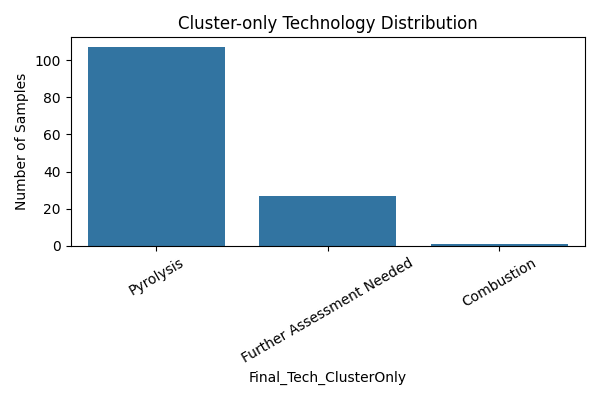

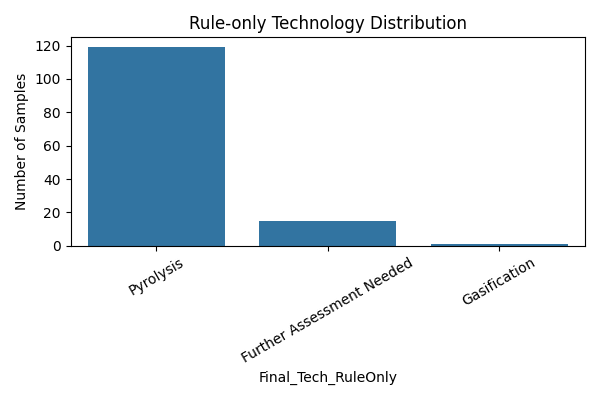

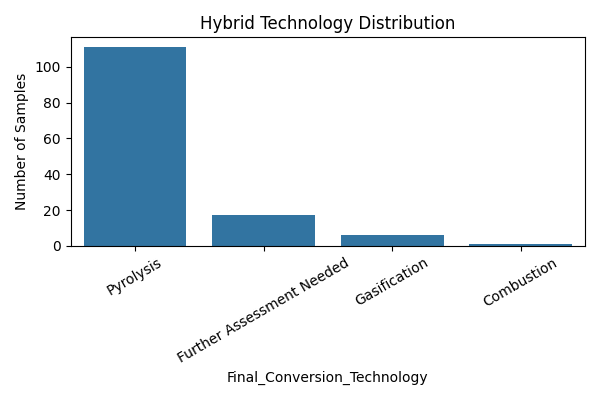

In [12]:
# 1. technology distribution
# Cluster-only
from IPython.display import Image, display

plot_technology_counts(
    df=df_vis,
    column="Final_Tech_ClusterOnly",
    title="Cluster-only Technology Distribution",
    output_path="../results/figures/phase5_comparison/bar/cluster_only_counts.png"
)
display(Image(filename="../results/figures/phase5_comparison/bar/cluster_only_counts.png"))

# Rule-only
plot_technology_counts(
    df=df_vis,
    column="Final_Tech_RuleOnly",
    title="Rule-only Technology Distribution",
    output_path="../results/figures/phase5_comparison/bar/rule_only_counts.png"
)
display(Image(filename="../results/figures/phase5_comparison/bar/rule_only_counts.png"))

# Hybrid (cluster+rule)
plot_technology_counts(
    df=df_vis,
    column="Final_Conversion_Technology",
    title="Hybrid Technology Distribution",
    output_path="../results/figures/phase5_comparison/bar/hybrid_counts.png"
)
display(Image(filename="../results/figures/phase5_comparison/bar/hybrid_counts.png"))


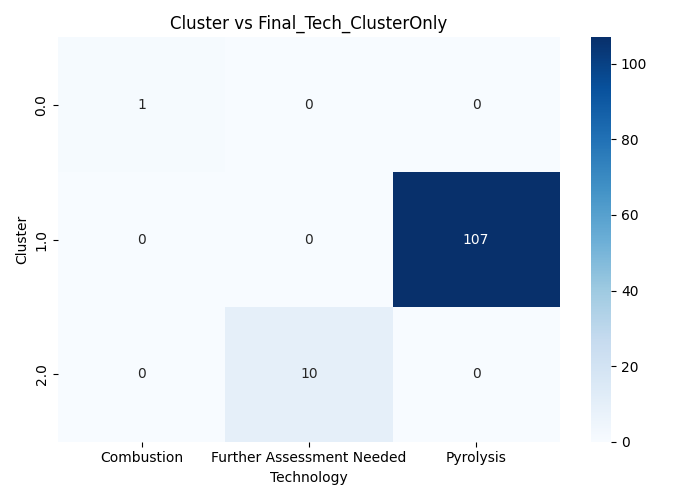

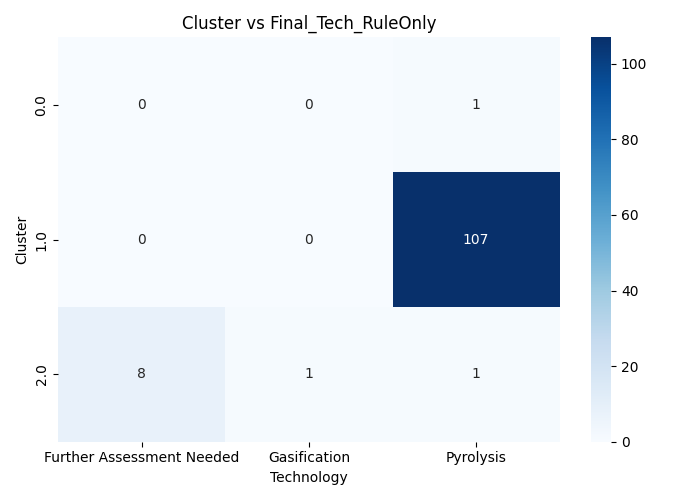

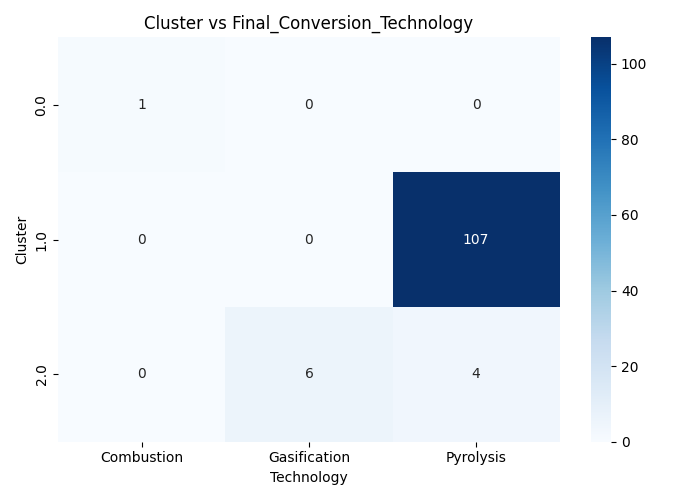

In [13]:
# Cluster vs technology(heatmaps)
# cluster only
plot_cluster_technology_heatmap(
    df=df_vis,
    tech_column="Final_Tech_ClusterOnly",
    output_path="../results/figures/phase5_comparison/heatmap/cluster_vs_cluster_only.png"
)
display(Image(filename="../results/figures/phase5_comparison/heatmap/cluster_vs_cluster_only.png"))

# rule only
plot_cluster_technology_heatmap(
    df=df_vis,
    tech_column="Final_Tech_RuleOnly",
    output_path="../results/figures/phase5_comparison/heatmap/cluster_vs_rule_only.png"
)
display(Image(filename="../results/figures/phase5_comparison/heatmap/cluster_vs_rule_only.png"))

# hybrid
plot_cluster_technology_heatmap(
    df=df_vis,
    tech_column="Final_Conversion_Technology",
    output_path="../results/figures/phase5_comparison/heatmap/cluster_vs_hybrid.png"
)
display(Image(filename="../results/figures/phase5_comparison/heatmap/cluster_vs_hybrid.png"))

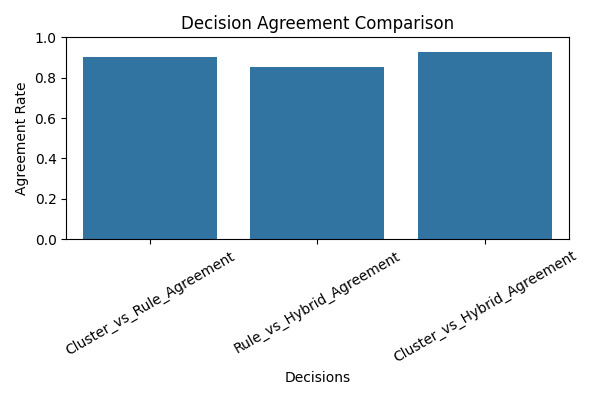

In [14]:
# 3. Agreement comparison
plot_agreement_rates(
    agreement_df,
    output_path="../results/figures/phase5_comparison/agreement/agreement_rates.png"
)
display(Image(filename="../results/figures/phase5_comparison/agreement/agreement_rates.png"))

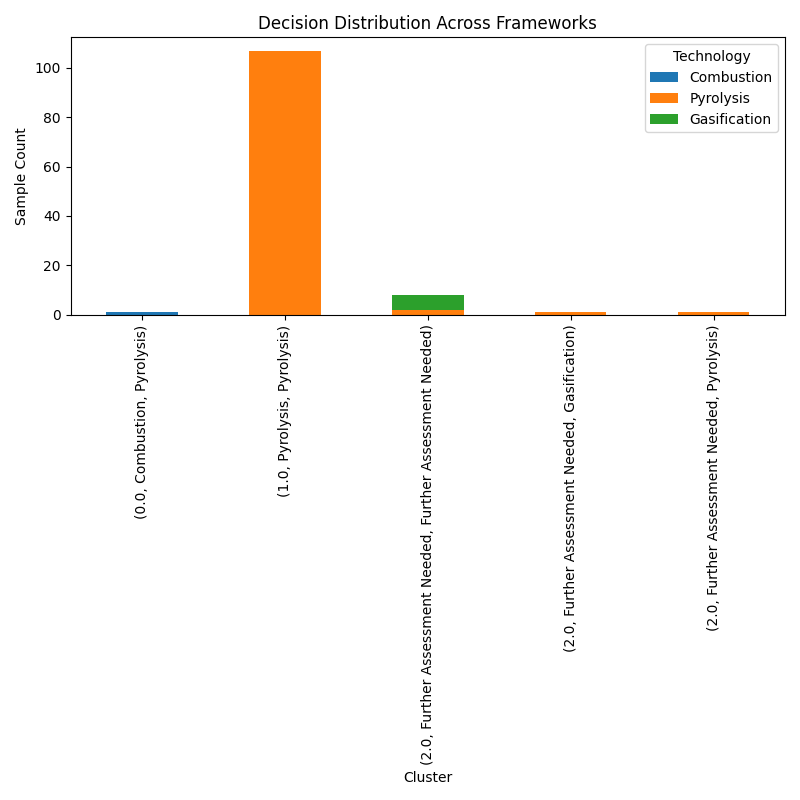

In [15]:
# 4. Decision flow across frameworks
plot_decision_flow(
    df=df_vis,
    output_path="../results/figures/phase5_comparison/sankey/decision_flow.png"
)
display(Image(filename="../results/figures/phase5_comparison/sankey/decision_flow.png"))